# Multi-Exit Dynamic Inference via Parameter-Efficient Fine-Tuning

## Objective
To implement and benchmark a multi-exit transformer architecture (FastBERT/DeeBERT paradigm) for dynamic inference using DistilBERT/DistilRoBERTa. The study evaluates computational efficiency (FLOPs/time) against accuracy degradation using Entropy and Energy-based gating mechanisms.

## Architecture
* **Base Models:** `distilbert-base-uncased` (6 layers).
* **PEFT Method:** LoRA (Rank=8) applied to attention weight matrices (`q_lin`, `v_lin`).
* **Exit Topology:** Linear classification heads attached to intermediate hidden states (e.g., layers 2, 4, 6).
* **Loss Function:** Uniformly weighted sum of cross-entropy losses from all exits: 
  $L_{total} = \sum_{i=1}^{N} \frac{1}{N} L_i$

## Datasets
* **MNLI:** 3-class natural language inference (Primary evaluation).


## Hardware Configuration
* **Environment:** Kaggle T4 GPU (16GB VRAM).
* **Memory Optimization:** Mixed Precision (FP16), LoRA, Gradient Accumulation.

In [1]:
!pip install -q transformers datasets peft accelerate evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.8 MB/s eta 0:00:00


In [ ]:
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModel, AutoConfig, TrainingArguments, Trainer
from datasets import load_dataset
from peft import LoraConfig, get_peft_model
from torch.cuda.amp import autocast

# Configuration
MODEL_NAME = "distilbert-base-uncased" 
DATASET_NAME = "glue"
TASK_NAME = "mnli" 
BATCH_SIZE = 32 
NUM_LABELS = 3 if TASK_NAME == "mnli" else 2
EXIT_LAYERS = [1, 3, 5] # 0-indexed layers (DistilBERT has 6 layers: 0 to 5)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def load_and_tokenize(task):
    dataset = load_dataset("glue", task)
    
    def tokenize_function(examples):
        if task == "mnli":
            return tokenizer(examples["premise"], examples["hypothesis"], padding="max_length", truncation=True, max_length=128)
        else:
            return tokenizer(examples["sentence"], padding="max_length", truncation=True, max_length=128)

    tokenized_datasets = dataset.map(tokenize_function, batched=True)
    return tokenized_datasets

tokenized_data = load_and_tokenize(TASK_NAME)
train_dataset = tokenized_data["train"]
eval_dataset = tokenized_data["validation_matched" if TASK_NAME == "mnli" else "validation"]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

Map:   0%|          | 0/392702 [00:00<?, ? examples/s]

Map:   0%|          | 0/9815 [00:00<?, ? examples/s]

Map:   0%|          | 0/9832 [00:00<?, ? examples/s]

Map:   0%|          | 0/9796 [00:00<?, ? examples/s]

Map:   0%|          | 0/9847 [00:00<?, ? examples/s]

In [4]:
class MultiExitDistilBert(nn.Module):
    def __init__(self, model_name, num_labels, exit_layers):
        super(MultiExitDistilBert, self).__init__()
        self.num_labels = num_labels
        self.exit_layers = exit_layers
        
        # 1. Load Base Model
        self.config = AutoConfig.from_pretrained(model_name)
        base_model = AutoModel.from_pretrained(model_name, config=self.config)
        
        # 2. Apply LoRA to base model
        # Target modules vary: distilbert uses q_lin, v_lin. RoBERTa uses query, value.
        target_modules = ["q_lin", "v_lin"] if "distilbert" in model_name else ["query", "value"]
        
        lora_config = LoraConfig(
            r=8, 
            lora_alpha=16, 
            target_modules=target_modules,
            lora_dropout=0.05, 
            bias="none", 
            task_type="FEATURE_EXTRACTION" 
        )
        self.encoder = get_peft_model(base_model, lora_config)
        
        # 3. Define Exit Heads (These remain fully trainable, not frozen)
        self.exits = nn.ModuleList([
            nn.Sequential(
                nn.Linear(self.config.hidden_size, self.config.hidden_size),
                nn.ReLU(),
                nn.Dropout(0.1),
                nn.Linear(self.config.hidden_size, num_labels)
            ) for _ in range(len(exit_layers))
        ])
        
        self.loss_fct = nn.CrossEntropyLoss()

    def forward(self, input_ids, attention_mask=None, labels=None, **kwargs):
        # Force model to output all hidden states
        outputs = self.encoder(
            input_ids=input_ids, 
            attention_mask=attention_mask, 
            output_hidden_states=True
        )
        
        hidden_states = outputs.hidden_states
        logits_list = []
        total_loss = 0.0

        # Extract [CLS] token equivalent (index 0) from required layers and pass to exit heads
        for i, layer_idx in enumerate(self.exit_layers):
            # hidden_states includes the embedding layer output at index 0, so layer 0 is hidden_states[1]
            layer_output = hidden_states[layer_idx + 1] 
            cls_output = layer_output[:, 0, :] 
            
            logits = self.exits[i](cls_output)
            logits_list.append(logits)
            
            if labels is not None:
                loss = self.loss_fct(logits.view(-1, self.num_labels), labels.view(-1))
                total_loss += loss

        # Uniform loss weighting
        if labels is not None:
            total_loss = total_loss / len(self.exit_layers)

        return {"loss": total_loss, "logits": logits_list}

model = MultiExitDistilBert(MODEL_NAME, NUM_LABELS, EXIT_LAYERS).to(device)
model.encoder.print_trainable_parameters()

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


trainable params: 147,456 || all params: 66,510,336 || trainable%: 0.2217


In [10]:
from torch.utils.data import DataLoader
from transformers import DataCollatorWithPadding
from torch.optim import AdamW
from tqdm.auto import tqdm

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

train_dataloader = DataLoader(
    train_dataset.remove_columns(["premise", "hypothesis", "idx"] if TASK_NAME == "mnli" else ["sentence", "idx"]),
    shuffle=True, 
    batch_size=BATCH_SIZE, 
    collate_fn=data_collator
)

optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=5e-4)

# Training Loop
num_epochs = 10
model.train()

for epoch in range(num_epochs):
    print(f"Epoch {epoch+1}/{num_epochs}")
    total_loss = 0
    
    for batch in tqdm(train_dataloader):
        batch = {k: v.to(device) for k, v in batch.items()}
        
        # Mixed precision for T4 memory constraints
        with autocast():
            outputs = model(**batch)
            loss = outputs["loss"]
            
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        
        total_loss += loss.item()
        
    print(f"Average Loss: {total_loss / len(train_dataloader)}")

Epoch 1/10


  0%|          | 0/12272 [00:00<?, ?it/s]

/tmp/ipykernel_55/1446476193.py:29: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Average Loss: 0.6478315483453299
Epoch 2/10


  0%|          | 0/12272 [00:00<?, ?it/s]

...

Average Loss: 0.617576214770217
Epoch 9/10


  0%|          | 0/12272 [00:00<?, ?it/s]

Average Loss: 0.6150249791230807
Epoch 10/10


  0%|          | 0/12272 [00:00<?, ?it/s]

Average Loss: 0.6131484257773712


In [11]:
import time
import numpy as np
import torch.nn.functional as F

def calculate_entropy(logits):
    """Calculates Shannon Entropy for a probability distribution."""
    probs = F.softmax(logits, dim=-1)
    # Add small epsilon to prevent log(0)
    entropy = -torch.sum(probs * torch.log(probs + 1e-9), dim=-1)
    return entropy

def calculate_energy(logits, temperature=1.0):
    """Calculates Energy score (often better for Out-of-Distribution)."""
    # E = -T * log(sum(exp(logits / T)))
    energy = -temperature * torch.logsumexp(logits / temperature, dim=-1)
    return energy

def dynamic_inference(model, input_ids, attention_mask, threshold, gating_type="entropy"):
    """
    Passes data through the model and exits early if the threshold is met.
    Returns: prediction, exit_layer_used
    """
    model.eval()
    with torch.no_grad():
        outputs = model.encoder(
            input_ids=input_ids, 
            attention_mask=attention_mask, 
            output_hidden_states=True
        )
        hidden_states = outputs.hidden_states
        
        for i, layer_idx in enumerate(model.exit_layers):
            # Extract representation for the exit head
            layer_output = hidden_states[layer_idx + 1]
            cls_output = layer_output[:, 0, :]
            
            # Get logits from the current exit
            logits = model.exits[i](cls_output)
            
            # Calculate Gating Metric
            if gating_type == "entropy":
                metric = calculate_entropy(logits).item()
                # Lower entropy = higher confidence
                confident = metric < threshold 
            elif gating_type == "energy":
                metric = calculate_energy(logits).item()
                # Lower energy = higher confidence (depending on formulation, tune threshold accordingly)
                confident = metric < threshold 
                
            if confident or i == len(model.exit_layers) - 1:
                # Exit early OR force exit at the final available head
                prediction = torch.argmax(logits, dim=-1).item()
                return prediction, i + 1 # Return exit level (1-indexed for logging)

# Example Usage:
# pred, exit_level = dynamic_inference(model, sample_input_ids, sample_mask, threshold=0.5, gating_type="entropy")

In [12]:
import time
from tqdm.auto import tqdm

def benchmark_gating_mechanism(model, eval_data, threshold, gating_type="entropy", num_samples=1000):
    """
    Evaluates the model on a subset of data to measure accuracy vs computational savings.
    """
    correct = 0
    total_exit_depth = 0
    total_time = 0
    
    # Use a subset of the validation data for faster benchmarking iterations
    subset = eval_data.select(range(min(num_samples, len(eval_data))))
    
    for item in tqdm(subset, desc=f"Testing {gating_type.upper()} | Threshold: {threshold}"):
        input_ids = torch.tensor([item["input_ids"]]).to(device)
        attention_mask = torch.tensor([item["attention_mask"]]).to(device)
        label = item["label"]
        
        start_time = time.time()
        pred, exit_level = dynamic_inference(model, input_ids, attention_mask, threshold, gating_type)
        total_time += (time.time() - start_time)
        
        if pred == label:
            correct += 1
        total_exit_depth += exit_level
        
    accuracy = correct / len(subset)
    avg_exit = total_exit_depth / len(subset)
    
    print(f"\n[Results] Gating: {gating_type.capitalize()} | Threshold: {threshold}")
    print(f"Accuracy:           {accuracy:.4f}")
    print(f"Average Exit Level: {avg_exit:.2f} (out of {len(model.exit_layers)})")
    print(f"Total Time:         {total_time:.2f} seconds\n")

# 1. Test Strict Entropy (Requires high confidence, likely exits later)
benchmark_gating_mechanism(model, eval_dataset, threshold=0.1, gating_type="entropy")

# 2. Test Relaxed Entropy (Allows lower confidence, exits earlier, saves more time)
benchmark_gating_mechanism(model, eval_dataset, threshold=0.6, gating_type="entropy")

# 3. Test Energy (Tuning the threshold depends heavily on your logits distribution)
benchmark_gating_mechanism(model, eval_dataset, threshold=-2.0, gating_type="energy")

Testing ENTROPY | Threshold: 0.1:   0%|          | 0/1000 [00:00<?, ?it/s]


[Results] Gating: Entropy | Threshold: 0.1
Accuracy:           0.7890
Average Exit Level: 2.80 (out of 3)
Total Time:         8.05 seconds



Testing ENTROPY | Threshold: 0.6:   0%|          | 0/1000 [00:00<?, ?it/s]


[Results] Gating: Entropy | Threshold: 0.6
Accuracy:           0.7860
Average Exit Level: 2.07 (out of 3)
Total Time:         7.90 seconds



Testing ENERGY | Threshold: -2.0:   0%|          | 0/1000 [00:00<?, ?it/s]


[Results] Gating: Energy | Threshold: -2.0
Accuracy:           0.7910
Average Exit Level: 2.71 (out of 3)
Total Time:         8.26 seconds



In [ ]:
import time
import pandas as pd
import torch
from tqdm.auto import tqdm

# Base compute estimations for DistilBERT (Seq Len 128)
# FLOPs are typically 2x MACs (Multiply-Accumulate Operations)
BASE_MACS = 5.5e9 

def comparative_analysis(model, eval_data, ent_thresh=0.5, eng_thresh=-2.0, num_samples=1000):
    subset = eval_data.select(range(min(num_samples, len(eval_data))))
    total_samples = len(subset)
    
    metrics = {
        "Full Inference": {"correct": 0, "time": 0.0, "exits": []},
        "Dynamic (Entropy)": {"correct": 0, "time": 0.0, "exits": []},
        "Dynamic (Energy)": {"correct": 0, "time": 0.0, "exits": []}
    }
    
    model.eval()
    max_exits = len(model.exit_layers)
    
    # GPU Warmup (prevents the first sample from skewing time metrics)
    dummy_input = torch.tensor([subset[0]["input_ids"]]).to(device)
    dummy_mask = torch.tensor([subset[0]["attention_mask"]]).to(device)
    _ = dynamic_inference(model, dummy_input, dummy_mask, threshold=0.5, gating_type="entropy")
    torch.cuda.synchronize()

    for item in tqdm(subset, desc="Running Comparative Benchmark"):
        input_ids = torch.tensor([item["input_ids"]]).to(device)
        attention_mask = torch.tensor([item["attention_mask"]]).to(device)
        label = item["label"]
        
        # 1. Full Inference 
        # (Threshold = -1 forces the model to fail the confidence check and use all layers)
        start = time.perf_counter()
        pred_full, exit_full = dynamic_inference(model, input_ids, attention_mask, threshold=-1.0, gating_type="entropy")
        torch.cuda.synchronize()
        metrics["Full Inference"]["time"] += (time.perf_counter() - start)
        if pred_full == label: metrics["Full Inference"]["correct"] += 1
        metrics["Full Inference"]["exits"].append(max_exits)
        
        # 2. Dynamic Inference (Entropy)
        start = time.perf_counter()
        pred_ent, exit_ent = dynamic_inference(model, input_ids, attention_mask, threshold=ent_thresh, gating_type="entropy")
        torch.cuda.synchronize()
        metrics["Dynamic (Entropy)"]["time"] += (time.perf_counter() - start)
        if pred_ent == label: metrics["Dynamic (Entropy)"]["correct"] += 1
        metrics["Dynamic (Entropy)"]["exits"].append(exit_ent)
        
        # 3. Dynamic Inference (Energy)
        start = time.perf_counter()
        pred_eng, exit_eng = dynamic_inference(model, input_ids, attention_mask, threshold=eng_thresh, gating_type="energy")
        torch.cuda.synchronize()
        metrics["Dynamic (Energy)"]["time"] += (time.perf_counter() - start)
        if pred_eng == label: metrics["Dynamic (Energy)"]["correct"] += 1
        metrics["Dynamic (Energy)"]["exits"].append(exit_eng)

    # Compile Results into a DataFrame
    results = []
    
    for method, data in metrics.items():
        acc = data["correct"] / total_samples
        avg_time_ms = (data["time"] / total_samples) * 1000 
        avg_exit = sum(data["exits"]) / total_samples
        
        # Calculate proportional computational cost
        layer_ratio = avg_exit / max_exits
        est_macs = BASE_MACS * layer_ratio
        est_flops = est_macs * 2 
        
        results.append({
            "Inference Mode": method,
            "Accuracy (%)": f"{acc * 100:.2f}",
            "Time/Sample (ms)": f"{avg_time_ms:.2f}",
            "Avg Exit Level": f"{avg_exit:.2f} / {max_exits}",
            "Est. MACs (G)": f"{est_macs / 1e9:.2f}",
            "Est. FLOPs (G)": f"{est_flops / 1e9:.2f}"
        })
        
    df = pd.DataFrame(results)
    return df

df_comparison = comparative_analysis(model, eval_dataset, ent_thresh=0.6, eng_thresh=-2.0, num_samples=1000)
display(df_comparison)

Running Comparative Benchmark:   0%|          | 0/1000 [00:00<?, ?it/s]

,Inference Mode,Accuracy (%),Time/Sample (ms),Avg Exit Level,Est. MACs (G),Est. FLOPs (G)
0,Full Inference,78.90,8.31,3.00 / 3,5.50,11.00
1,Dynamic (Entropy),78.60,7.86,2.07 / 3,3.80,7.60
2,Dynamic (Energy),79.10,8.18,2.71 / 3,4.97,9.94


Mapping Exit Distributions:   0%|          | 0/1000 [00:00<?, ?it/s]

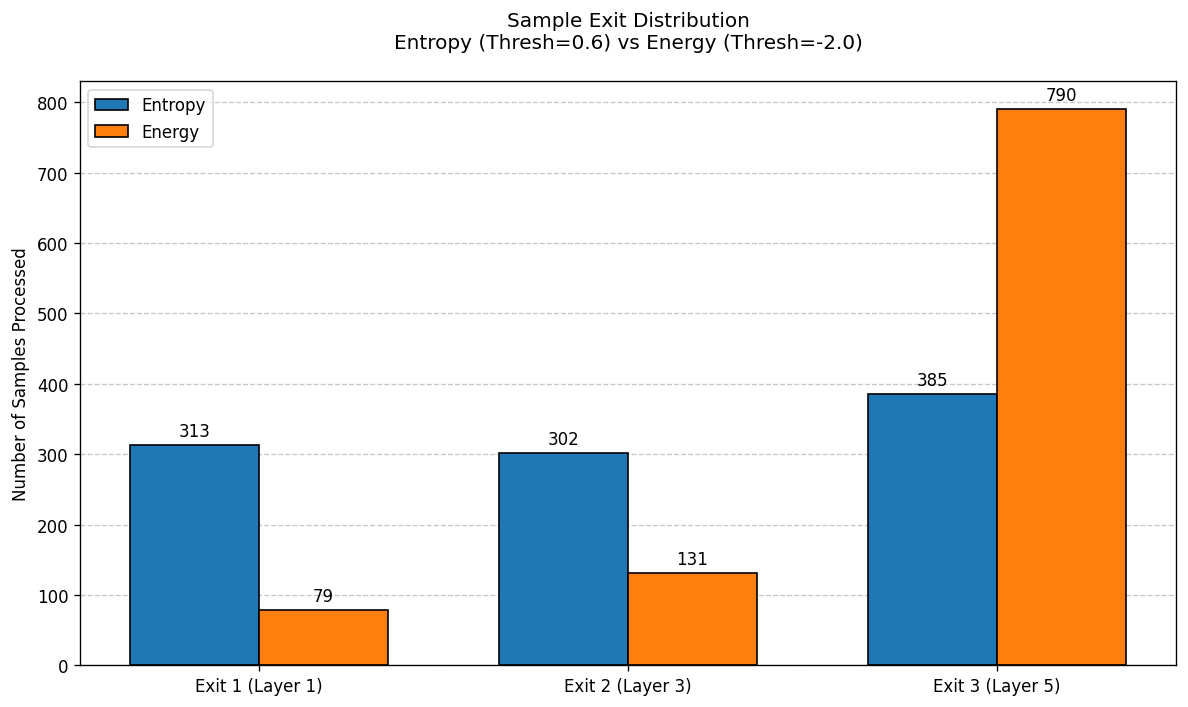

In [14]:
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
from tqdm.auto import tqdm
import torch

def plot_exit_distribution(model, eval_data, ent_thresh=0.6, eng_thresh=-2.0, num_samples=1000):
    subset = eval_data.select(range(min(num_samples, len(eval_data))))
    
    entropy_exits = []
    energy_exits = []
    
    model.eval()
    for item in tqdm(subset, desc="Mapping Exit Distributions"):
        input_ids = torch.tensor([item["input_ids"]]).to(device)
        attention_mask = torch.tensor([item["attention_mask"]]).to(device)
        
        # Track Entropy Exit Layer
        _, exit_ent = dynamic_inference(model, input_ids, attention_mask, threshold=ent_thresh, gating_type="entropy")
        entropy_exits.append(exit_ent)
        
        # Track Energy Exit Layer
        _, exit_eng = dynamic_inference(model, input_ids, attention_mask, threshold=eng_thresh, gating_type="energy")
        energy_exits.append(exit_eng)
        
    # Tally frequencies for each exit level
    ent_counts = Counter(entropy_exits)
    eng_counts = Counter(energy_exits)
    
    num_exits = len(model.exit_layers)
    labels = [f"Exit {i+1} (Layer {model.exit_layers[i]})" for i in range(num_exits)]
    x = np.arange(len(labels))
    width = 0.35
    
    # Extract counts mapping 1-indexed exit levels
    ent_values = [ent_counts.get(i+1, 0) for i in range(num_exits)]
    eng_values = [eng_counts.get(i+1, 0) for i in range(num_exits)]
    
    # Plot Configuration
    fig, ax = plt.subplots(figsize=(10, 6), dpi=120)
    rects1 = ax.bar(x - width/2, ent_values, width, label='Entropy', color='#1f77b4', edgecolor='black')
    rects2 = ax.bar(x + width/2, eng_values, width, label='Energy', color='#ff7f0e', edgecolor='black')
    
    ax.set_ylabel('Number of Samples Processed')
    ax.set_title(f'Sample Exit Distribution\nEntropy (Thresh={ent_thresh}) vs Energy (Thresh={eng_thresh})', pad=20)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.legend()
    
    # Attach numeric labels above bars
    ax.bar_label(rects1, padding=3)
    ax.bar_label(rects2, padding=3)
    
    # Add gridlines for readibility
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.set_axisbelow(True)
    
    fig.tight_layout()
    plt.show()

# Execution
plot_exit_distribution(model, eval_dataset, ent_thresh=0.6, eng_thresh=-2.0, num_samples=1000)